#  Light Statistical Analysis

**Goal**: Quick pass over event frequencies and correlations. We're keeping this light — just enough to build intuition before we dive deep into sequence and temporal patterns.

**Key questions**:
1. Which events are most/least common?
2. Do any events correlate strongly with each other?
3. Which events are most different between Normal and Anomaly blocks?
4. Can a simple PCA reveal any cluster structure?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
DATA_DIR = "../../preprocessed"
matrix_df = pd.read_csv(os.path.join(DATA_DIR, "Event_occurrence_matrix.csv"))
templates_df = pd.read_csv(os.path.join(DATA_DIR, "HDFS.log_templates.csv"))

# Separate event columns from metadata columns
event_cols = [col for col in matrix_df.columns if col.startswith('E')]
print(f" Loaded {matrix_df.shape[0]:,} blocks × {len(event_cols)} event types")


✅ Loaded 575,061 blocks × 29 event types


##  Which events happen most?

By summing each event column across ALL blocks, we see the system's overall "behavior profile". Events that appear millions of times are the **backbone** of normal operations. Events that appear rarely might be error signals.


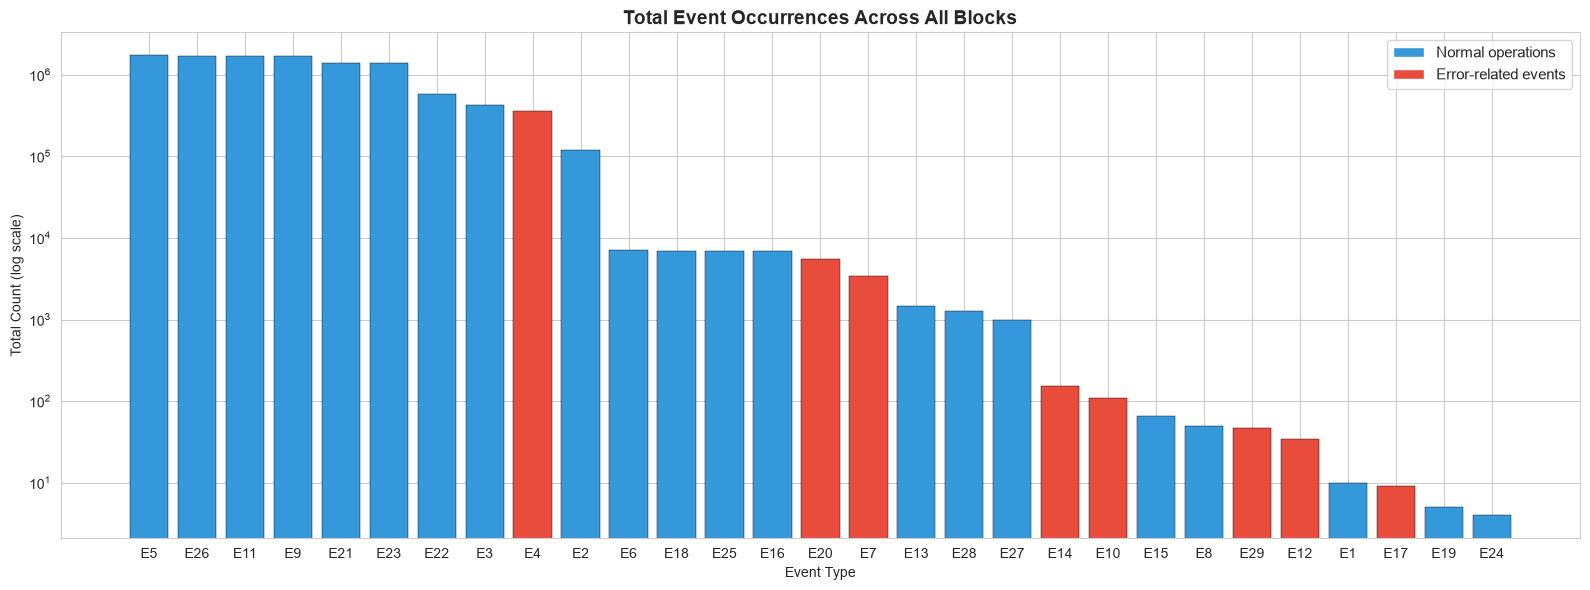


🔝 Top 5 most frequent events:
   E5:    1,723,232  │ [*]Receiving block[*]src:[*]dest:[*]
   E26:    1,719,741  │ [*]BLOCK* NameSystem[*]addStoredBlock: blockMap updated:[*]is added to[*]size[*]
   E11:    1,706,679  │ [*]PacketResponder[*]for block[*]terminating[*]
   E9:    1,706,514  │ [*]Received block[*]of size[*]from[*]
   E21:    1,402,047  │ [*]Deleting block[*]file[*]

🔻 Bottom 5 least frequent events:
   E12:           34  │ [*]:Exception writing block[*]to mirror[*]
   E1:           10  │ [*]Adding an already existing block[*]
   E17:            9  │ [*]:Failed to transfer[*]to[*]got[*]
   E19:            5  │ [*]Reopen Block[*]
   E24:            4  │ [*]BLOCK* Removing block[*]from neededReplications as it does not belong to any file[*]


In [2]:
# Sum each event across all blocks
event_totals = matrix_df[event_cols].sum().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#e74c3c' if eid in ['E4','E7','E10','E12','E14','E17','E20','E29'] 
          else '#3498db' for eid in event_totals.index]

bars = ax.bar(event_totals.index, event_totals.values, color=colors, edgecolor='black', linewidth=0.3)
ax.set_title('Total Event Occurrences Across All Blocks', fontsize=14, fontweight='bold')
ax.set_xlabel('Event Type')
ax.set_ylabel('Total Count (log scale)')
ax.set_yscale('log')  # Log scale because some events are 1000x more frequent

# Add a legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Normal operations'),
                   Patch(facecolor='#e74c3c', label='Error-related events')]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/event_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 and bottom 5
print("\n🔝 Top 5 most frequent events:")
for eid, count in event_totals.head(5).items():
    tmpl = templates_df[templates_df['EventId']==eid]['EventTemplate'].values[0]
    print(f"   {eid}: {count:>12,}  │ {tmpl}")

print("\n🔻 Bottom 5 least frequent events:")
for eid, count in event_totals.tail(5).items():
    tmpl = templates_df[templates_df['EventId']==eid]['EventTemplate'].values[0]
    print(f"   {eid}: {count:>12,}  │ {tmpl}")


##  Normal vs. Anomaly: Which events differ most?

This is the most informative chart in this notebook. For each event, we compare the **average count** in Normal blocks vs. Anomaly blocks. Events with a big gap between the two bars are the ones that **signal** anomalies.

We'll use a metric called **mean ratio** = mean_anomaly / mean_normal. A ratio of 10× means anomalies have 10 times more of that event on average.


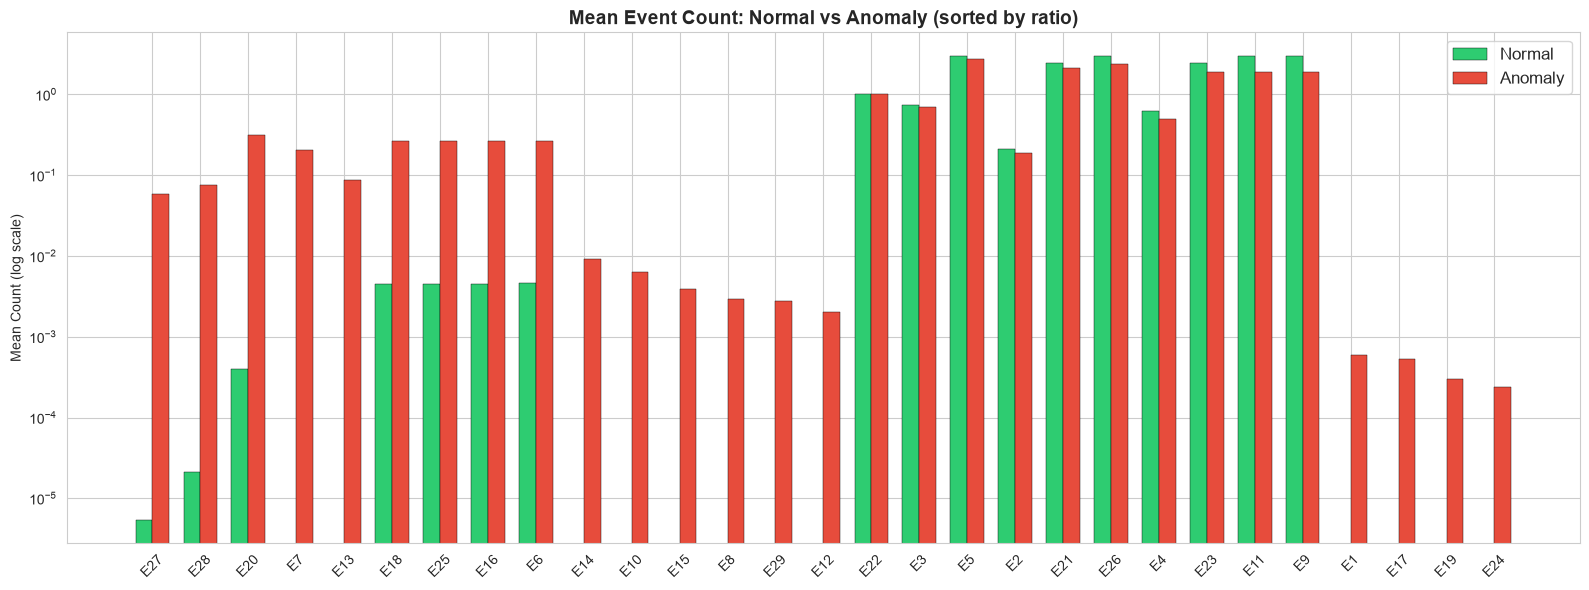


🎯 Most discriminative events (Anomaly/Normal ratio):

   Event     Normal Mean   Anomaly Mean    Ratio
   ──────────────────────────────────────────────
   E27              0.00           0.06  10741.4×
   E28              0.00           0.08   3525.2×
   E20              0.00           0.32    794.9×
   E7               0.00           0.20    202.9×
   E13              0.00           0.09     86.9×
   E18              0.00           0.26     58.1×
   E25              0.00           0.26     58.1×
   E16              0.00           0.26     57.3×
   E6               0.00           0.27     56.8×
   E14              0.00           0.01      9.2×
   E10              0.00           0.01      6.4×
   E15              0.00           0.00      3.9×
   E8               0.00           0.00      2.9×
   E29              0.00           0.00      2.8×
   E12              0.00           0.00      2.0×
   E22              1.00           1.00      1.0×
   E3               0.75           0.70      0

In [ ]:
# Split into normal and anomaly groups
normal_mask  = matrix_df['Label'] == 'Success'
anomaly_mask = matrix_df['Label'] == 'Fail'

normal_means  = matrix_df.loc[normal_mask, event_cols].mean()
anomaly_means = matrix_df.loc[anomaly_mask, event_cols].mean()

# Build comparison DataFrame
comparison = pd.DataFrame({
    'Normal_Mean': normal_means,
    'Anomaly_Mean': anomaly_means,
})
# Avoid division by zero
comparison['Ratio'] = comparison['Anomaly_Mean'] / comparison['Normal_Mean'].replace(0, 0.001)
comparison = comparison.sort_values('Ratio', ascending=False)

# Plot side-by-side bars
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(event_cols))
width = 0.35

# Re-order event_cols by the ratio
ordered_events = comparison.index.tolist()

ax.bar(x - width/2, comparison['Normal_Mean'], width, label='Normal', color='#2ecc71', edgecolor='black', linewidth=0.3)
ax.bar(x + width/2, comparison['Anomaly_Mean'], width, label='Anomaly', color='#e74c3c', edgecolor='black', linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(ordered_events, rotation=45)
ax.set_yscale('log')
ax.set_title('Mean Event Count: Normal vs Anomaly (sorted by ratio)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Count (log scale)')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/normal_vs_anomaly_events.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the top discriminative events
print("\n Most discriminative events (Anomaly/Normal ratio):\n")
print(f"   {'Event':<8} {'Normal Mean':>12} {'Anomaly Mean':>14} {'Ratio':>8}")
print(f"   {'─'*46}")
for eid, row in comparison.iterrows():
    print(f"   {eid:<8} {row['Normal_Mean']:>12.2f} {row['Anomaly_Mean']:>14.2f} {row['Ratio']:>8.1f}×")


##  PCA:

**PCA (Principal Component Analysis)** takes our 29-dimensional data and projects it down to 2 dimensions while keeping as much variance (information) as possible. 

If Normal and Anomaly blocks separate into distinct clusters in 2D, it means the event patterns ARE different enough to distinguish — which is exactly what our CoT agent will exploit.


Variance explained: PC1=19.5%, PC2=15.4%, Total=34.8%


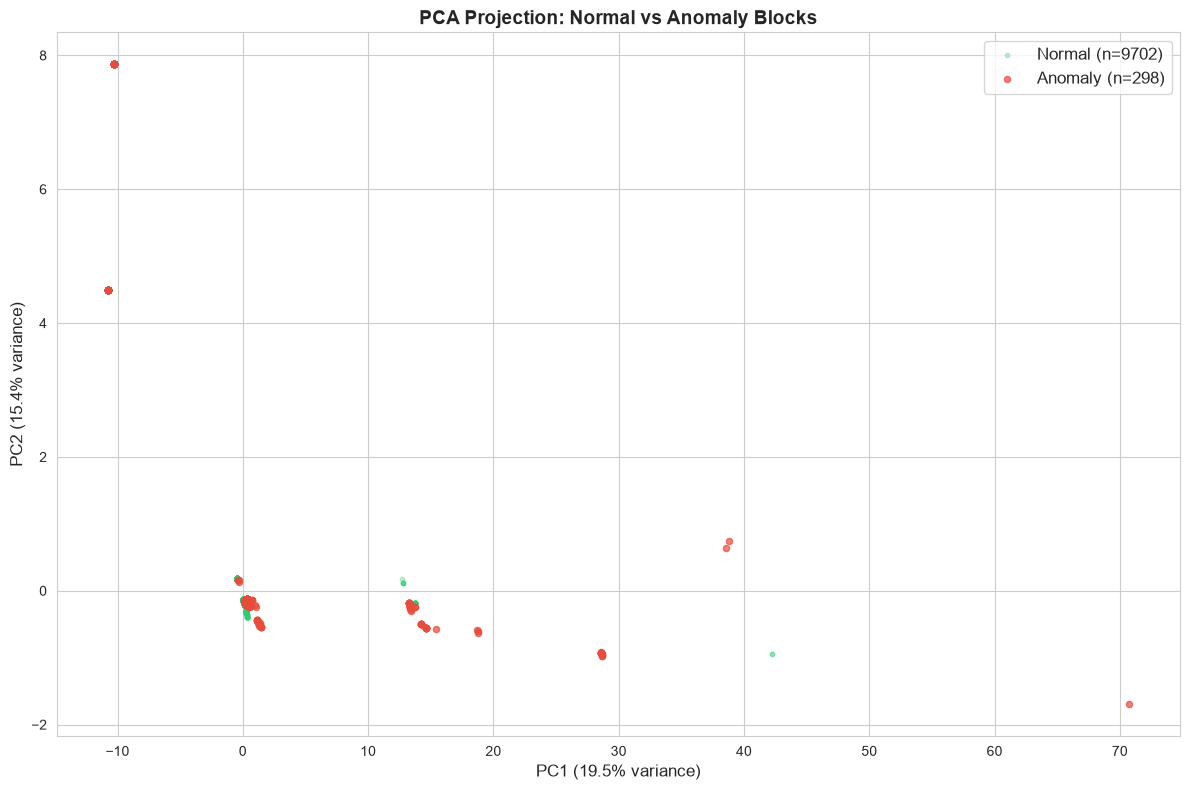

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



scaler = StandardScaler()
X_scaled = scaler.fit_transform(matrix_df[event_cols])

# Fit PCA — reduce 29 dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much information did we keep?
print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca.explained_variance_ratio_):.1%}")


np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=10000, replace=False)

fig, ax = plt.subplots(figsize=(12, 8))
labels = matrix_df['Label'].values


normal_idx = sample_idx[labels[sample_idx] == 'Success']
anomaly_idx = sample_idx[labels[sample_idx] == 'Fail']

ax.scatter(X_pca[normal_idx, 0], X_pca[normal_idx, 1], 
           c='#2ecc71', alpha=0.3, s=10, label=f'Normal (n={len(normal_idx)})')
ax.scatter(X_pca[anomaly_idx, 0], X_pca[anomaly_idx, 1], 
           c='#e74c3c', alpha=0.7, s=20, label=f'Anomaly (n={len(anomaly_idx)})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA Projection: Normal vs Anomaly Blocks', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
